In [89]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from skimage.measure import find_contours
from operator import le, lt, ge, gt, ne, eq

def calculate_shoreline_length_ratio(img_path):
    """Calculate the shoreline length ratio for labeled water body images.

    Args:
        img_path (str): Path to the folder containing binary segmentation images.

    Returns:
        dict: A dictionary mapping image names to their shoreline length ratio.
    """
    img_files = [f for f in os.listdir(img_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    shoreline_ratios = {}

    for img_name in tqdm(img_files, desc="Calculating Shoreline Length Ratios"):
        img_path_full = os.path.join(img_path, img_name)
        img = np.array(cv2.imread(img_path_full, cv2.IMREAD_GRAYSCALE))  # Read as grayscale

        if img is None:
            print(f"Error reading {img_name}, skipping.")
            continue

        binary_img = img > 1  # Assuming 1 represents water
        contours = find_contours(binary_img, level=0.5)
        
        image_height, image_width = img.shape
        non_boundary_edge_pixels = 0

        for contour in contours:
            for x, y in contour:
                x, y = int(round(x)), int(round(y))  # Convert to integer pixel coordinates
                if 0 < x < image_height - 1 and 0 < y < image_width - 1:  # Ignore edge pixels
                    non_boundary_edge_pixels += 1

        shoreline_ratio = non_boundary_edge_pixels / image_width  # Normalize by image width
        shoreline_ratios[img_name] = shoreline_ratio

    return shoreline_ratios

def calculate_edge_lengths(img_path, option=1):
    """Calculate the distribution of water body edge lengths in labeled images."""
    img_files = [f for f in os.listdir(img_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    edge_lengths = []
    
    for img_name in tqdm(img_files, desc="Calculating Edge Lengths"):
        img_path_full = os.path.join(img_path, img_name)
        img = np.array(cv2.imread(img_path_full, cv2.IMREAD_GRAYSCALE))  # Read as grayscale
        
        if img is None:
            print(f"Error reading {img_name}, skipping.")
            continue
        
        binary_img = img > 1  # Assuming 1 represents water
        contours = find_contours(binary_img, level=0.5)
        
        for contour in contours:
            if option == 2:
                # Split contour into segments if they touch the image boundary
                split_contours = []
                current_segment = []
                for i in range(len(contour)):
                    x, y = contour[i]
                    if x == 0 or x == img.shape[0] - 1 or y == 0 or y == img.shape[1] - 1:
                        if current_segment:
                            split_contours.append(np.array(current_segment))
                            current_segment = []
                    else:
                        current_segment.append((x, y))
                if current_segment:
                    split_contours.append(np.array(current_segment))
                
                # Compute lengths of valid segments
                for segment in split_contours:
                    if len(segment) > 1:
                        edge_lengths.append(np.sum(np.sqrt(np.sum(np.diff(segment, axis=0) ** 2, axis=1))))
            else:
                # Compute length normally
                edge_lengths.append(np.sum(np.sqrt(np.sum(np.diff(contour, axis=0) ** 2, axis=1))))
    
    return edge_lengths

def calculate_water_body_area(img_path, option = 1):
    """Calculate the water body area as a percentage of image size."""
    img_files = [f for f in os.listdir(img_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    water_areas = []
    
    for img_name in tqdm(img_files, desc="Calculating Water Body Areas"):
        img_path_full = os.path.join(img_path, img_name)
        img = np.array(cv2.imread(img_path_full, cv2.IMREAD_GRAYSCALE))  # Read as grayscale
        
        if img is None:
            print(f"Error reading {img_name}, skipping.")
            continue
        
        total_pixels = img.size
        water_pixels = np.sum(img >0)  # Assuming 1 represents water
        if option == 1:
            water_areas.append((water_pixels / total_pixels) * 100)
        else:
            if water_pixels > 0 and water_pixels < total_pixels:
                water_areas.append((water_pixels / total_pixels) * 100)
    
    return water_areas

def calculate_hue_distribution(img_path, mask_path):
    """
    Calculate the average hue value for each image in img_path, using only the pixels 
    where the corresponding mask image (from mask_path) is non-zero.

    Args:
        img_path (str): Path to the folder containing the images.
        mask_path (str): Path to the folder containing the mask images.
                         Masks must share the same file names as the images.
    
    Returns:
        list: A list of average hue values (one per image).
    """
    img_files = [f for f in os.listdir(img_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    average_hue_values = []
    
    for img_name in tqdm(img_files, desc="Calculating Hue Values"):
        img_file = os.path.join(img_path, img_name)
        mask_file = os.path.join(mask_path, img_name)
        
        img = cv2.imread(img_file)
        mask = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"Error reading image {img_name}, skipping.")
            continue
        
        if mask is None:
            print(f"Error reading mask {img_name}, skipping.")
            continue
        
        # Convert image to HSV and extract the hue channel.
        img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        hue_channel = img_hsv[:, :, 0]
        
        # Extract R, G, B channels from the original image
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]

        # Create a mask for white pixels (R > 250, G > 250, B > 250)
        white_pixel_mask = (R > 250) & (G > 250) & (B > 250)

        # Only consider pixels where the mask is non-zero AND they are NOT white
        valid_hue = hue_channel[(mask != 0) & (~white_pixel_mask)]

        if valid_hue.size == 0:
            print(f"No valid non-white pixels in mask for {img_name}, skipping.")
            continue
        
        # Compute the average hue of valid pixels.
        average_hue = np.median(valid_hue)
        average_hue_values.append(average_hue)
    
    return average_hue_values

def count_ratio(lst, threshold, operator_str="<="):
    operators = {
        "<=": le,
        "<": lt,
        ">=": ge,
        ">": gt,
        "!=": ne,
        "==": eq
    }
    
    if operator_str not in operators:
        raise ValueError(f"Invalid operator '{operator_str}'. Choose from: {list(operators.keys())}")

    op_func = operators[operator_str]
    return sum(1 for x in lst if op_func(x, threshold)) / len(lst)

def plot_histogram(data, bins=10, xlabel="X-axis", ylabel="Y-axis", title="Histogram", 
                   figsize=(8, 6), color="blue", edgecolor="black", alpha=0.7, 
                   grid=True, grid_style="--", grid_alpha=0.5,
                   connect_bins=False, line_color="red", line_style="-", line_width=2,
                   xlim=None, ylim=None, tick_label_size=12, 
                   xlabel_size=14, ylabel_size=14, title_size=16, 
                   save_path=None, dpi=300, percent=True):
    """
    Efficient histogram plotting using NumPy for fast calculations with percentage option
    and integer-based y-axis labels.

    Args:
        data (array-like): Data for the histogram.
        bins (int or sequence): Number of bins or bin edges.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
        title (str): Title of the plot.
        figsize (tuple): Figure size (width, height).
        color (str): Color of the bars.
        edgecolor (str): Color of the bar edges.
        alpha (float): Transparency level (0 to 1).
        grid (bool): Whether to show the grid.
        grid_style (str): Line style for the grid.
        grid_alpha (float): Transparency of the grid lines.
        connect_bins (bool): Whether to connect bin midpoints with a line.
        line_color (str): Color of the connecting line.
        line_style (str): Line style for the connecting line.
        line_width (float): Line width for the connecting line.
        xlim (tuple or None): x-axis limits.
        ylim (tuple or None): y-axis limits.
        tick_label_size (int): Font size for tick labels.
        xlabel_size (int): Font size for x-axis label.
        ylabel_size (int): Font size for y-axis label.
        title_size (int): Font size for the title.
        save_path (str or None): File path to save the figure.
        dpi (int): Resolution of saved figure.
        percent (bool): If True, normalizes the histogram to percentage values.
    """
    plt.figure(figsize=figsize)

    # Compute histogram using NumPy
    counts, bin_edges = np.histogram(data, bins=bins)

    if percent:
        counts = counts / counts.sum() * 100  # Convert to percentage
        ylabel = "Percentage (%)"  # Change y-axis label

    # Plot histogram using plt.bar
    plt.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), color=color, edgecolor=edgecolor, alpha=alpha, align='edge')

    # If enabled, connect bin midpoints with a line
    if connect_bins:
        bin_midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2
        plt.plot(bin_midpoints, counts, linestyle=line_style, linewidth=line_width, color=line_color)

    # Set labels and title
    plt.xlabel(xlabel, fontsize=xlabel_size)
    plt.ylabel(ylabel, fontsize=ylabel_size)
    plt.title(title, fontsize=title_size)

    # Set axis limits if provided
    if xlim:
        plt.xlim(xlim)
    # Determine the y-axis limits
    if ylim:
        plt.ylim(ylim)
        y_max = ylim[1]  # Use provided ylim
    else:
        y_max = np.ceil(max(counts))  # Auto scale to max count

    # Set evenly spaced integer y-ticks based on y_max
    y_ticks_step = max(1, int(y_max / 4))  # Ensure step is at least 1
    y_ticks = np.arange(0, y_max, y_ticks_step)
    plt.yticks(y_ticks, fontsize=tick_label_size)
    plt.xticks(fontsize=tick_label_size)
    # Ensure y-axis labels are integers

    # Configure grid
    if grid:
        plt.grid(True, linestyle=grid_style, alpha=grid_alpha)

    # Save the plot if a save path is provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', pad_inches=0)

    plt.show()


In [10]:
GT_path = "/home/weiwang/ResearchProjects/mmsegmentation/Label_500/Label_500/"
img_path = "/home/weiwang/ResearchProjects/mmsegmentation/Label_500/Img_500/"
hue_values = calculate_hue_distribution(img_path, GT_path)

Calculating Hue Values:   1%|          | 187/20689 [00:01<01:51, 183.77it/s]

No valid non-white pixels in mask for img_19433.png, skipping.


Calculating Hue Values:   2%|▏         | 379/20689 [00:02<01:48, 187.03it/s]

No valid non-white pixels in mask for img_5834.png, skipping.


Calculating Hue Values:   4%|▍         | 835/20689 [00:04<01:47, 183.84it/s]

...

No valid non-white pixels in mask for img_8602.png, skipping.


Calculating Hue Values: 100%|█████████▉| 20630/20689 [01:53<00:00, 181.62it/s]

No valid non-white pixels in mask for img_412.png, skipping.


Calculating Hue Values: 100%|██████████| 20689/20689 [01:53<00:00, 182.51it/s]

No valid non-white pixels in mask for img_12379.png, skipping.


0.22960197799001308
0.09565133078004558


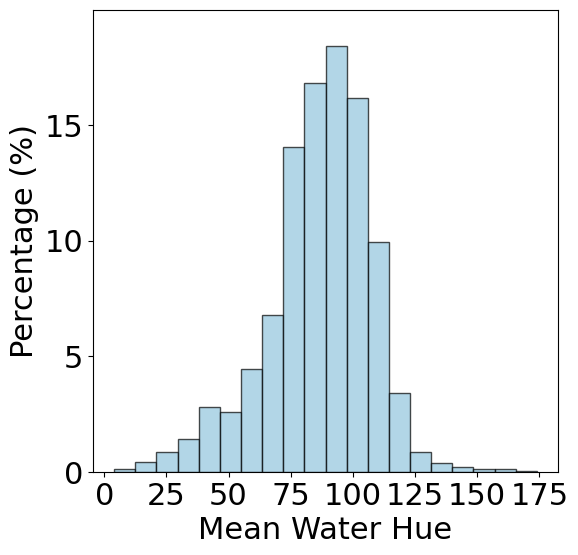

In [92]:
save_path = "/home/weiwang/ResearchProjects/mmsegmentation/BenchPlots/"
os.makedirs(save_path, exist_ok=True)
print(count_ratio(hue_values, 75, "<"))
print(count_ratio(hue_values, 110, ">"))
plot_histogram(hue_values, bins=20, xlabel="Mean Water Hue", ylabel="Frequency", title="",
               figsize=(6, 6), color="#92c5de", edgecolor="black", alpha=0.7, grid=False, grid_style="--", grid_alpha=0.5,
               connect_bins=False, line_color="red", line_style="-", line_width=2, xlim=None, ylim=(0,20),
               tick_label_size=22, xlabel_size=22, ylabel_size=22, title_size=16, save_path=save_path + 'Hue.jpg', dpi=600)

In [30]:
waterbody_areas = calculate_water_body_area(GT_path, option=1)


Calculating Water Body Areas: 100%|██████████| 20689/20689 [00:24<00:00, 828.50it/s]


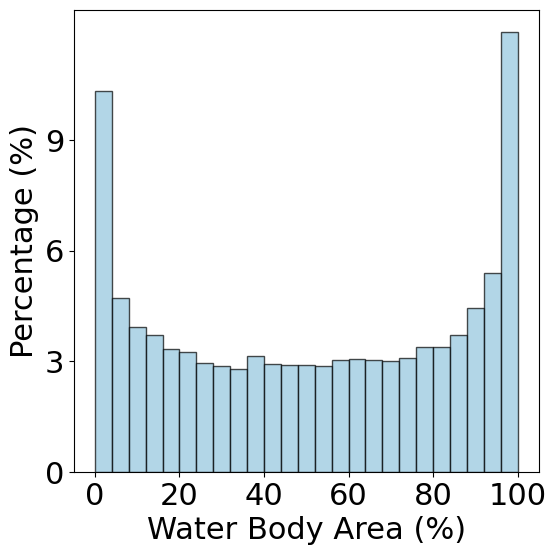

In [86]:
plot_histogram(waterbody_areas, bins=25, xlabel="Water Body Area (%)", ylabel="Frequency", title="",
               figsize=(6, 6), color="#92c5de", edgecolor="black", alpha=0.7, grid=False, grid_style="--", grid_alpha=0.5,
               connect_bins=False, line_color="red", line_style="-", line_width=2, xlim=None, ylim=None,
               tick_label_size=22, xlabel_size=22, ylabel_size=22, title_size=16, save_path=save_path + 'waterbody.jpg', dpi=600)

In [32]:
shoreline_ratios = calculate_shoreline_length_ratio(GT_path)


Calculating Shoreline Length Ratios: 100%|██████████| 20689/20689 [01:42<00:00, 200.92it/s]


0.3142732853207018
0.1272173618831263


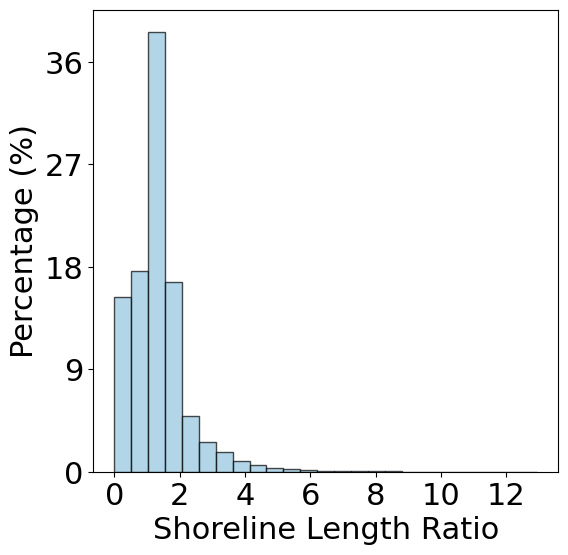

In [98]:
print(count_ratio(list(shoreline_ratios.values()), 1, "<"))
print(count_ratio(list(shoreline_ratios.values()), 2, ">"))
plot_histogram(list(shoreline_ratios.values()), bins=25, xlabel="Shoreline Length Ratio", ylabel="Frequency", title="",
               figsize=(6, 6), color="#92c5de", edgecolor="black", alpha=0.7, grid=False, grid_style="--", grid_alpha=0.5,
               connect_bins=False, line_color="black", line_style="-", line_width=0.5, xlim=None, ylim=None,
               tick_label_size=22, xlabel_size=22, ylabel_size=22, title_size=16, save_path=save_path + 'shoreline.jpg', dpi=600)